2025-01-04 23:31:18.169125: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-04 23:31:18.177376: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-04 23:31:18.249241: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-04 23:31:18.313585: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1736001078.395722   26477 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1736001078.41

Train Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1981520 entries, 0 to 1981519
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytess                  float64
 15  Flow Packetss                float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max               

/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/utils/extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/utils/extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/utils/extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Scaled train features shape: (1981520, 55)

Processing features for the validation dataset...
Validation features (numeric): (424611, 54)
Validation features (categorical): (424611, 0)

Encoding categorical features in validation data...

Combined validation features (before scaling):
    Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0                53          23637                  2                       2   
1               443             44                  2                       0   
2             59214              3                  2                       0   
3               443              5                  3                       0   
4                80      116542556                  8                       7   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                           76                          108   
1                            0                            0   
2                           12       

/tmp/ipykernel_26477/432265042.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=column, data=data, palette='Set2')


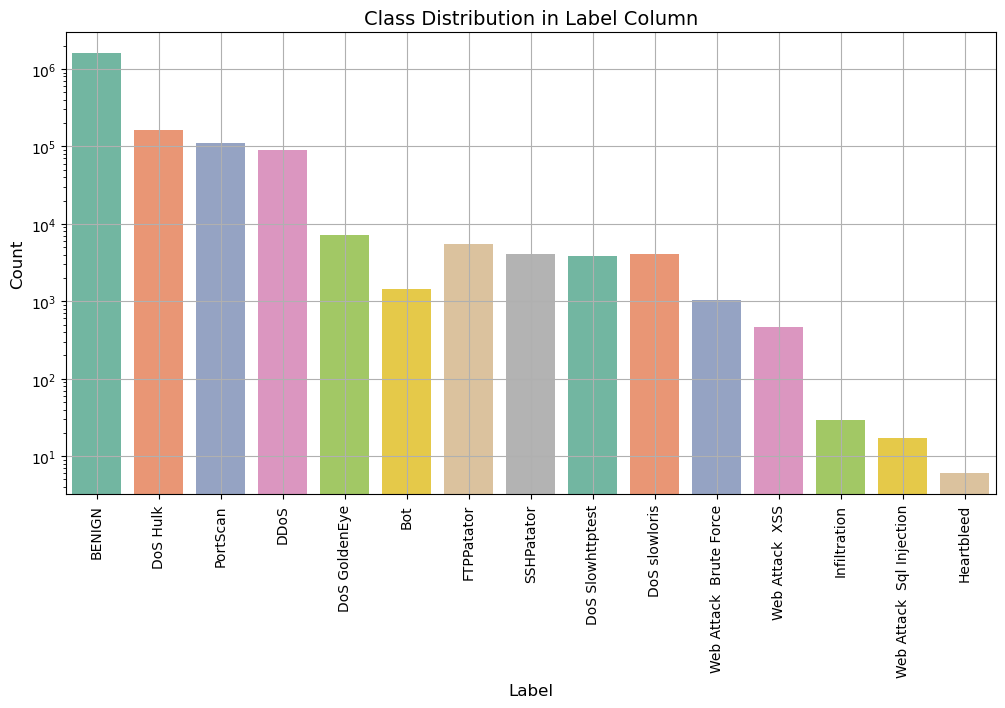

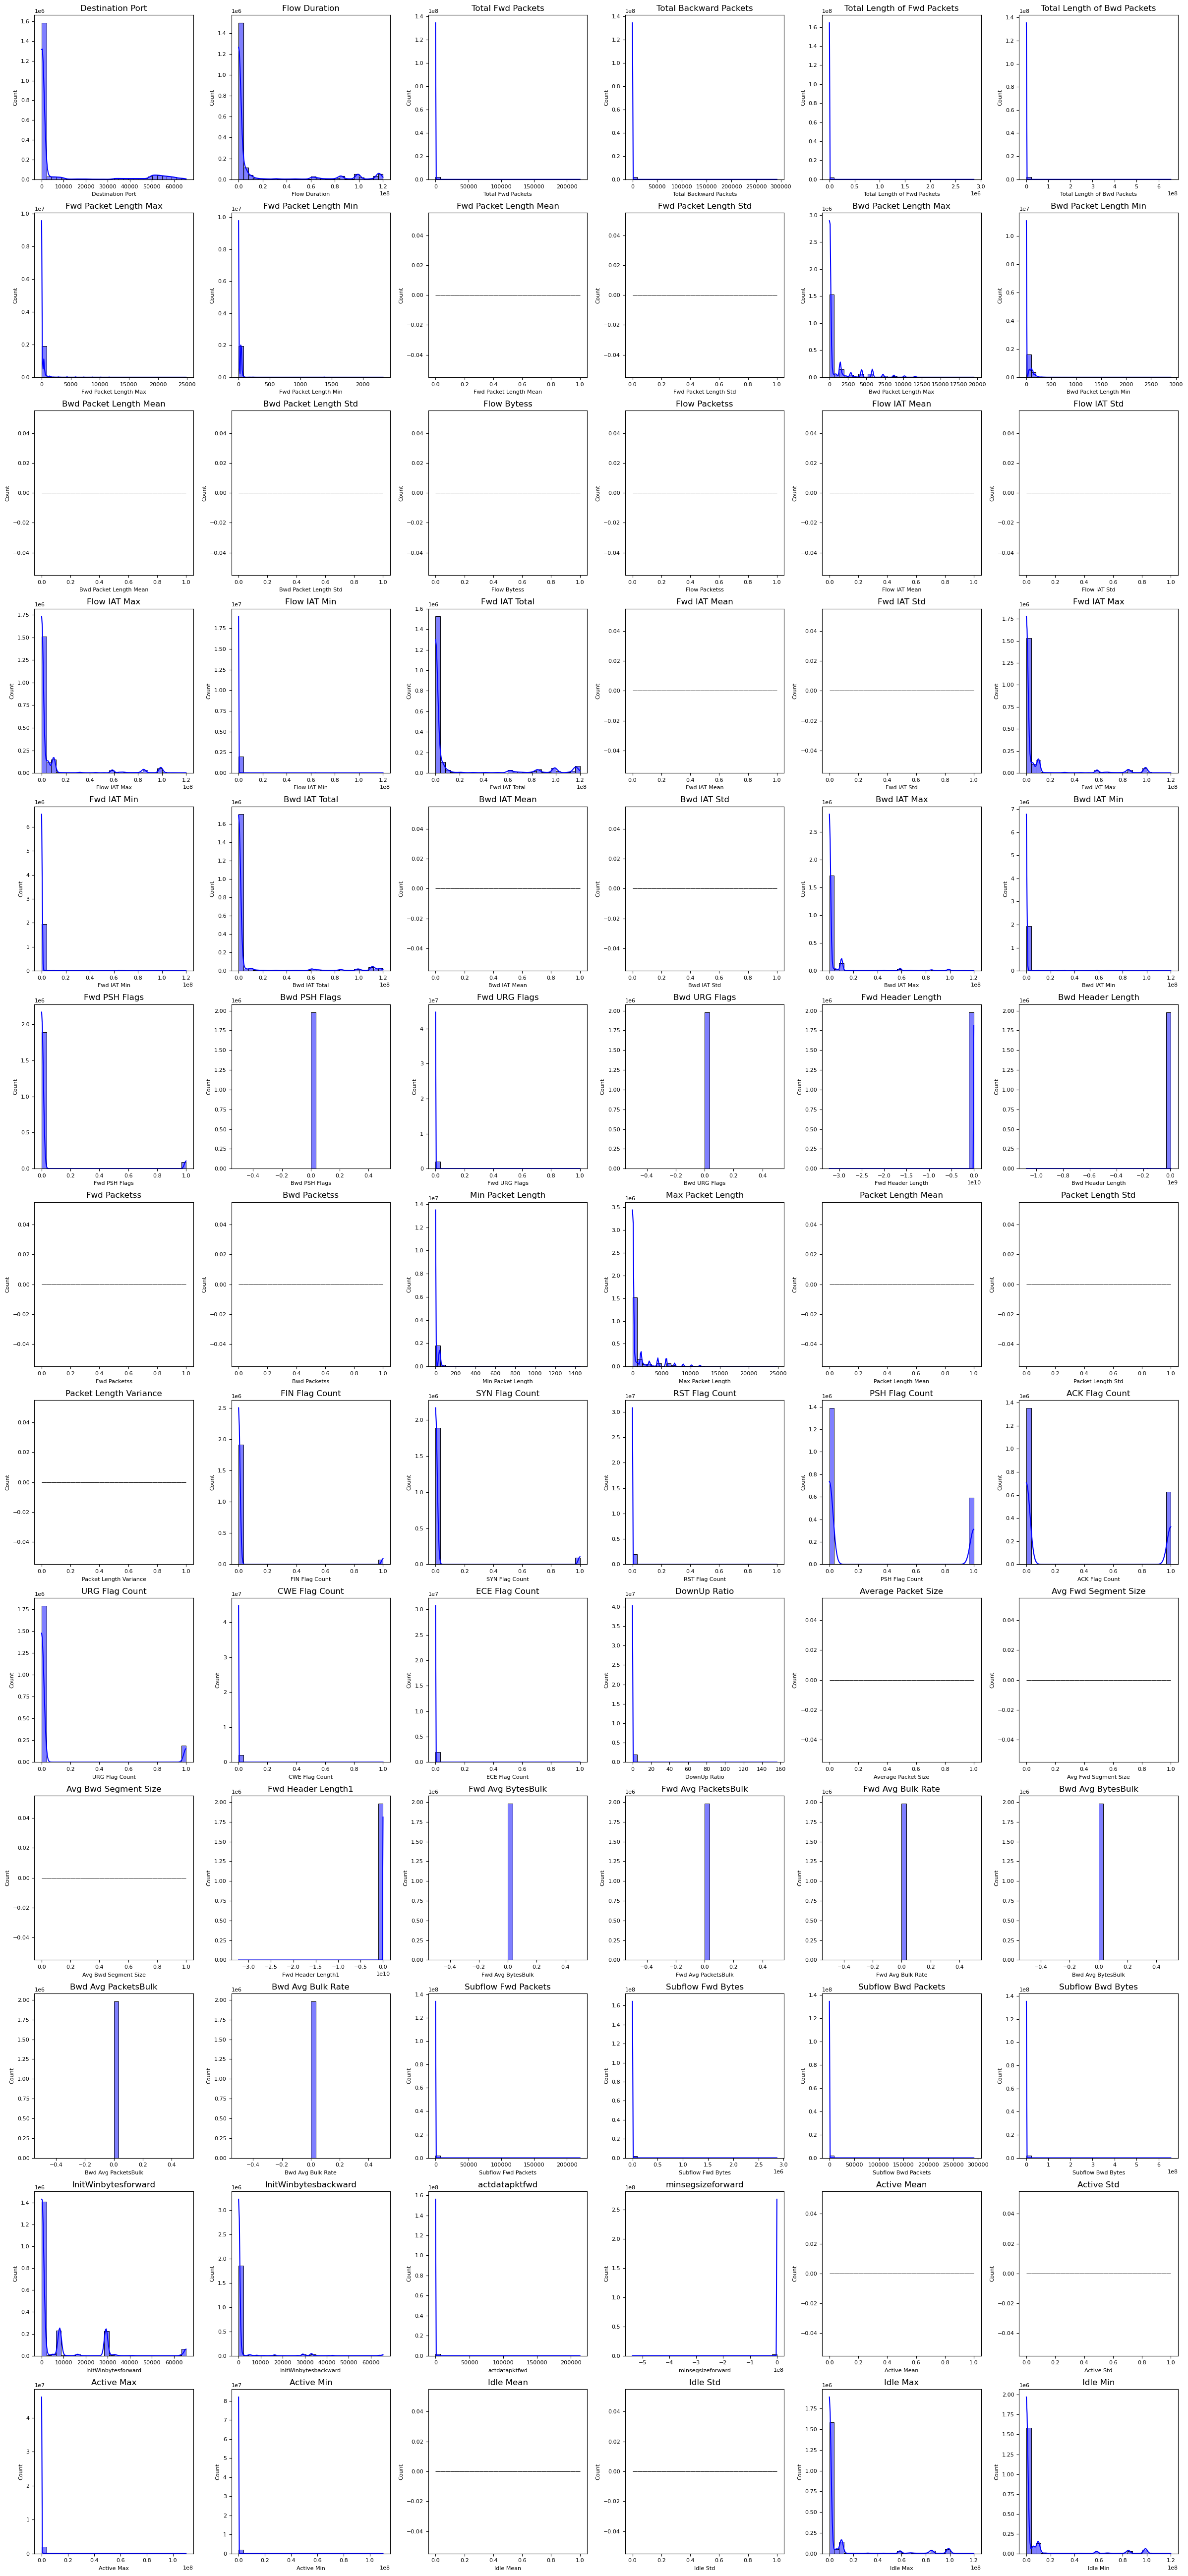

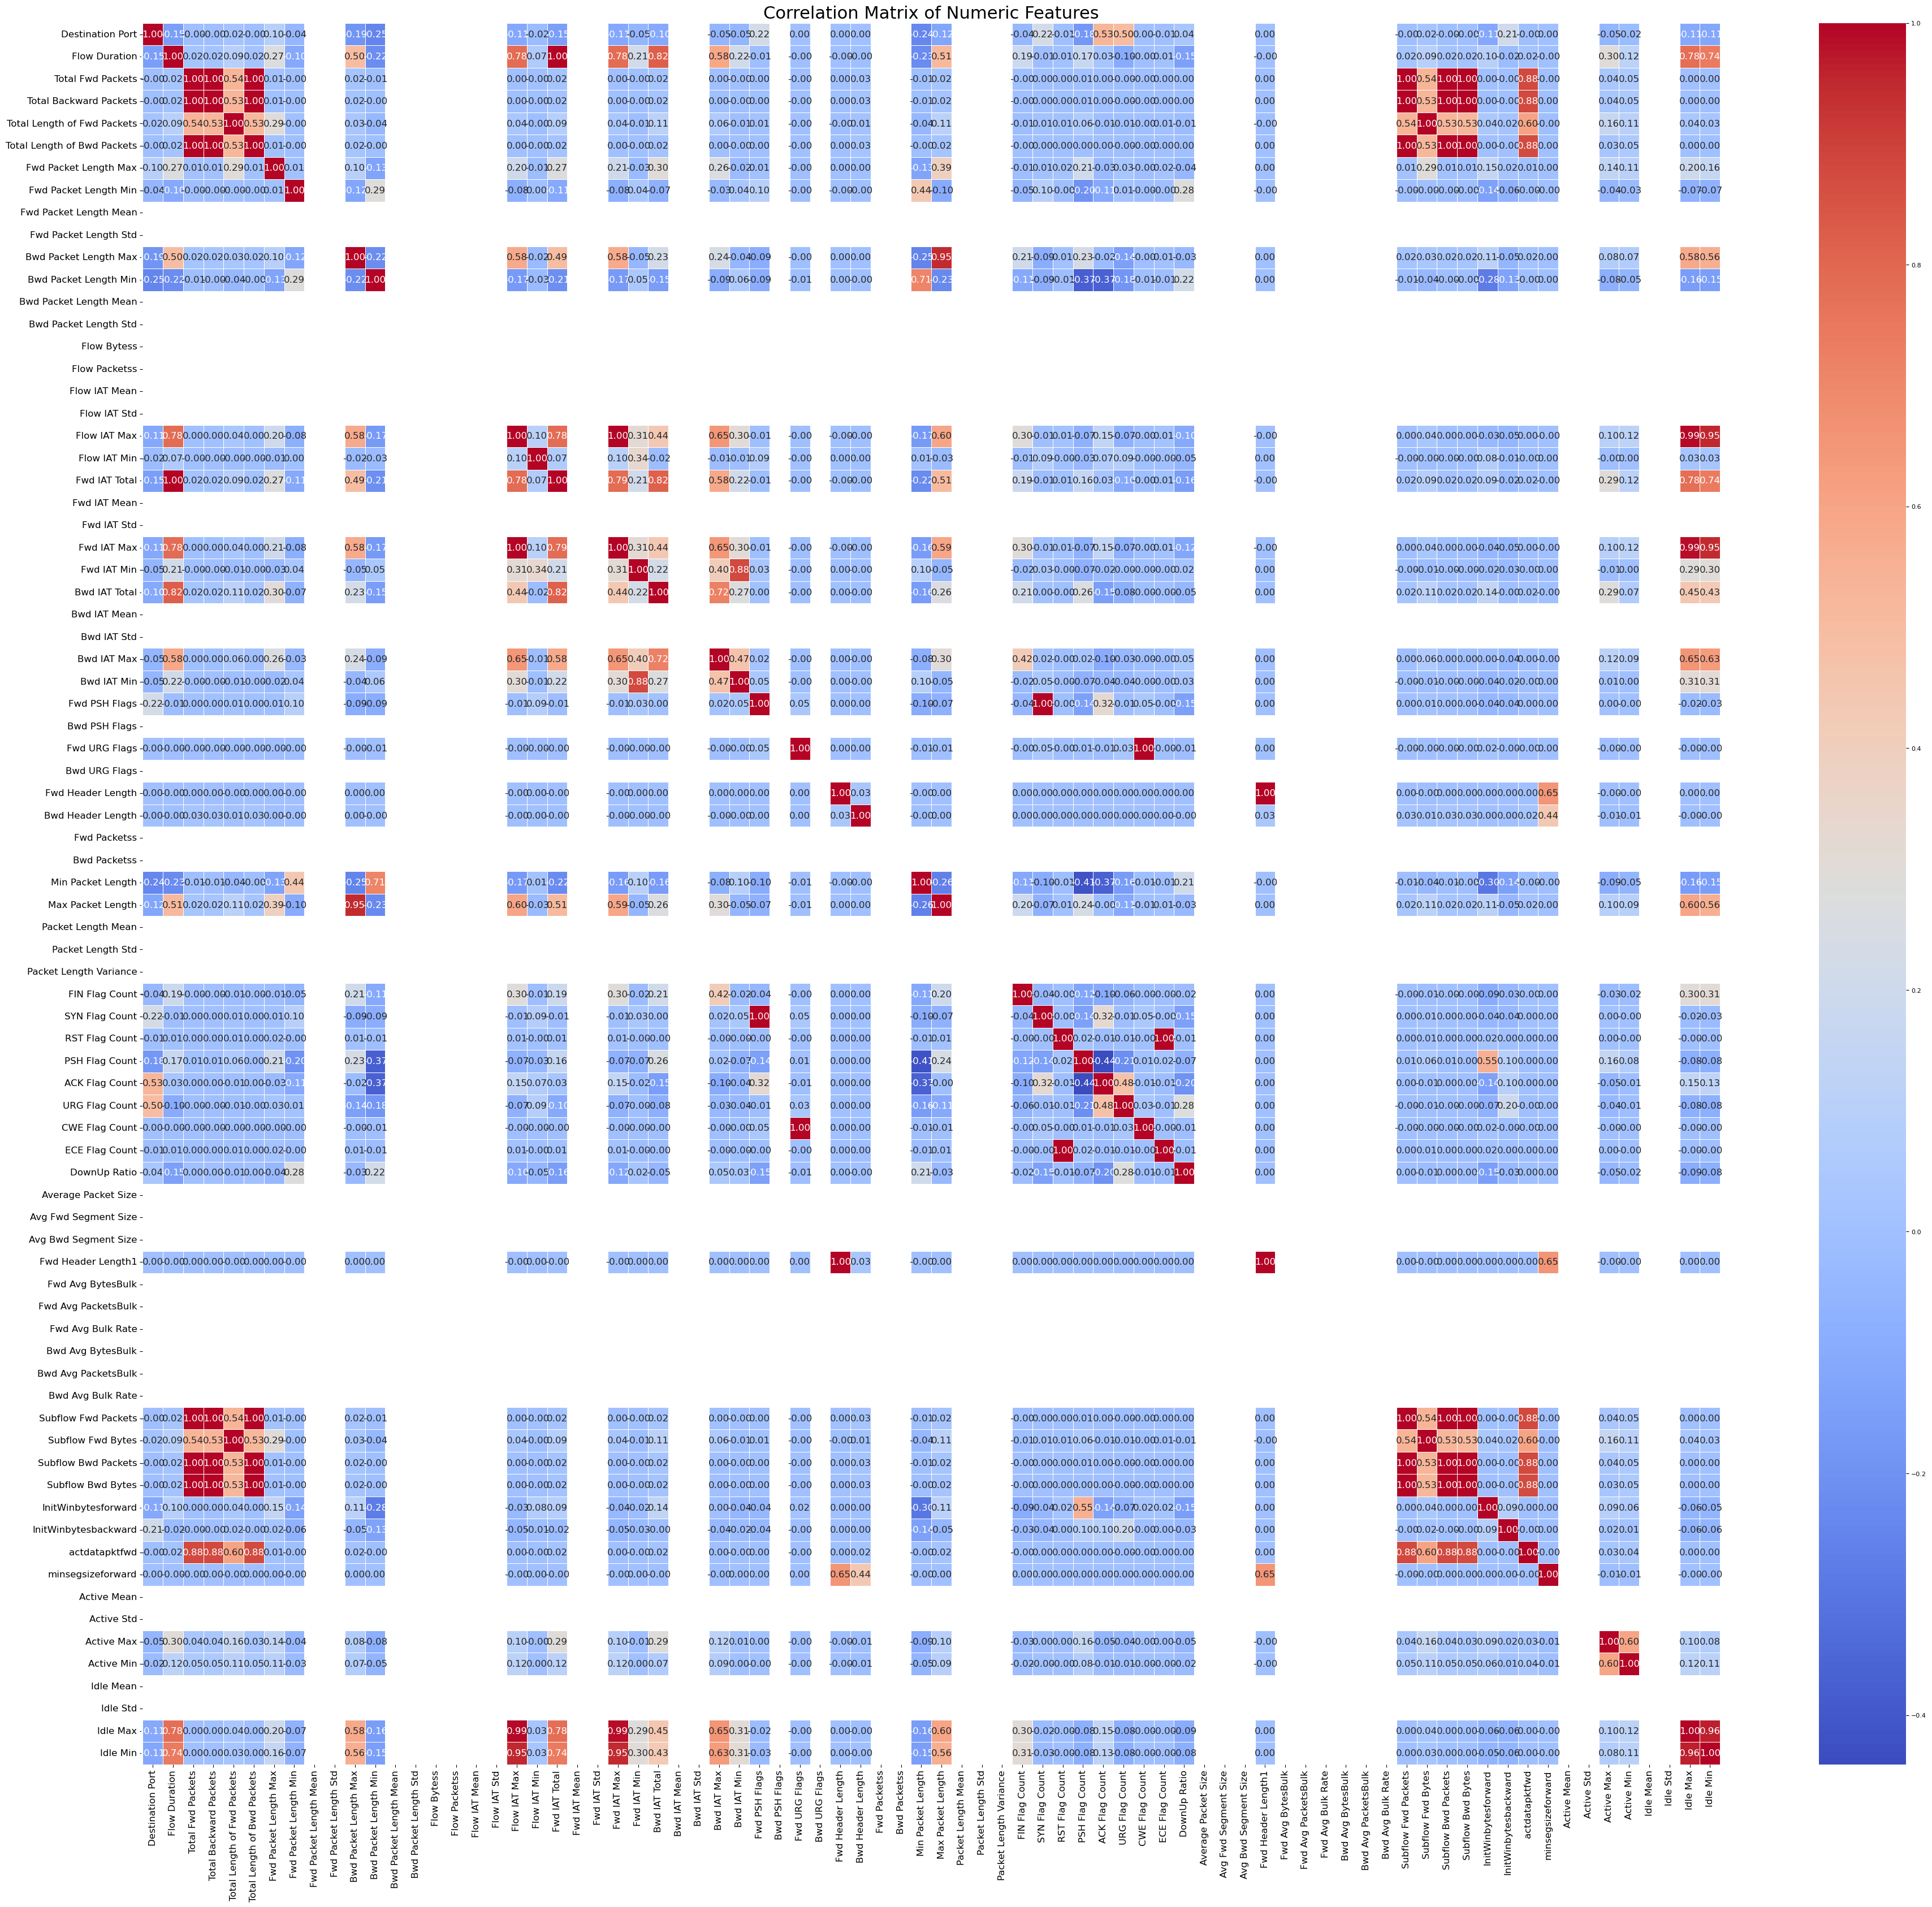

In [1]:
import import_ipynb
%run CICIDS_2017_data_preprocessing.ipynb


Validation Accuracy: 0.998921
Test Accuracy: 0.998926
RF_accuracy: 0.998926


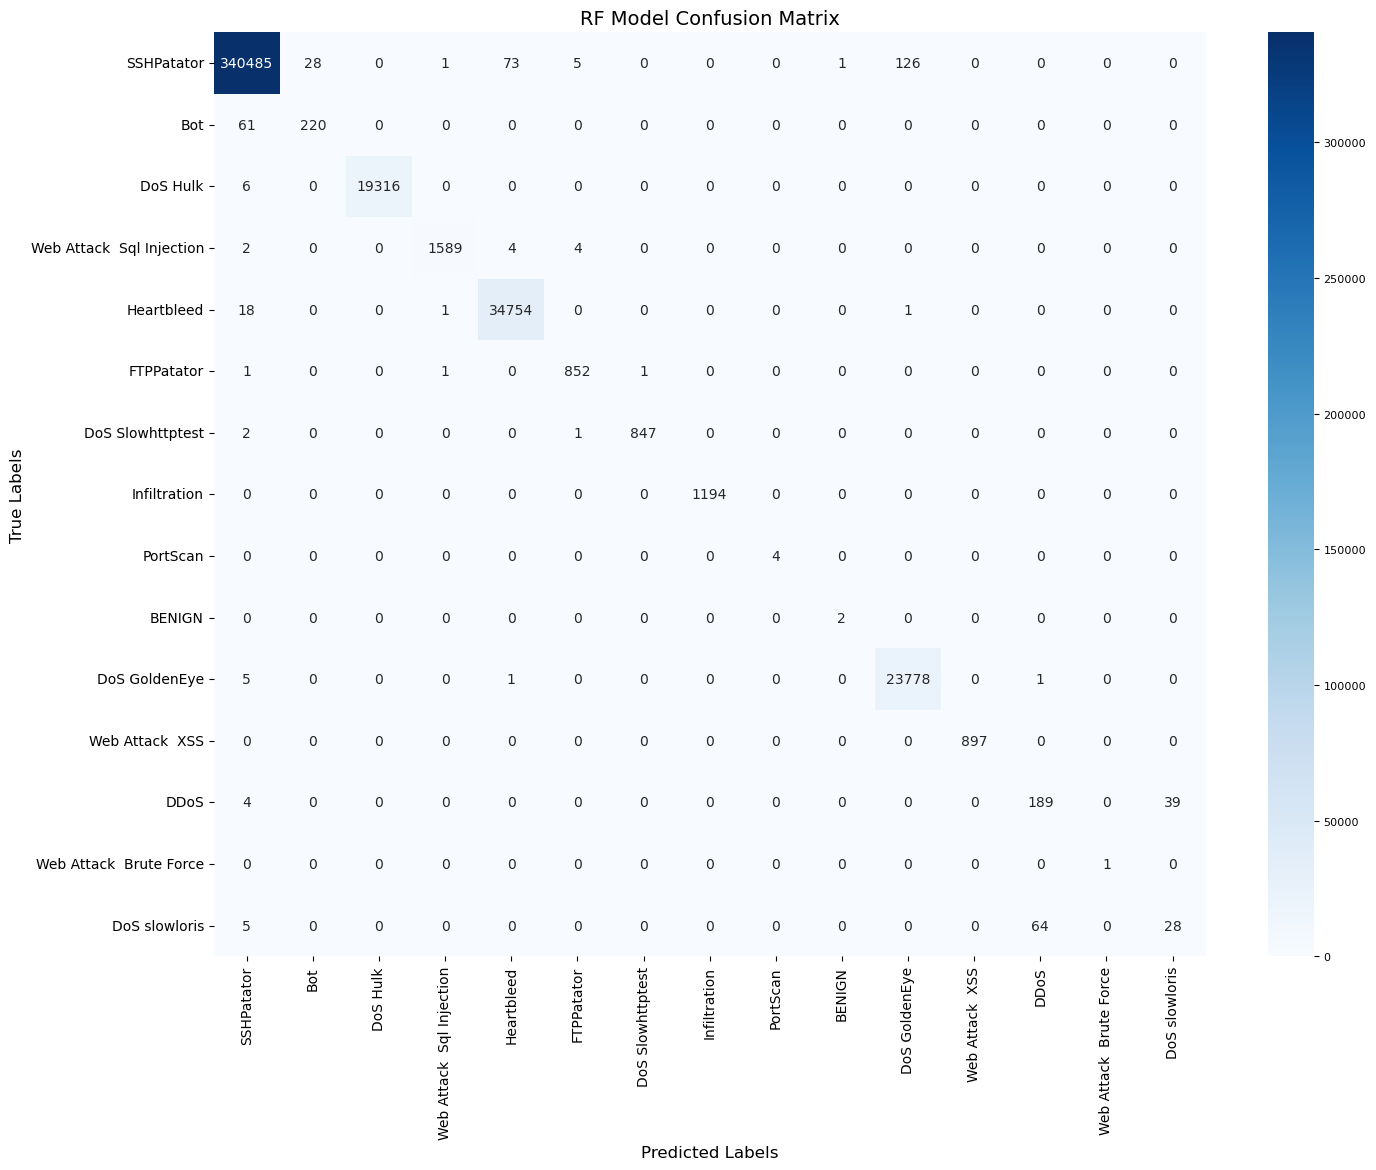

RF Model Classification Report:
                           precision    recall  f1-score   support

               SSHPatator       1.00      1.00      1.00    340719
                      Bot       0.89      0.78      0.83       281
                 DoS Hulk       1.00      1.00      1.00     19322
Web Attack  Sql Injection       1.00      0.99      1.00      1599
               Heartbleed       1.00      1.00      1.00     34774
               FTPPatator       0.99      1.00      0.99       855
         DoS Slowhttptest       1.00      1.00      1.00       850
             Infiltration       1.00      1.00      1.00      1194
                 PortScan       1.00      1.00      1.00         4
                   BENIGN       0.67      1.00      0.80         2
            DoS GoldenEye       0.99      1.00      1.00     23785
          Web Attack  XSS       1.00      1.00      1.00       897
                     DDoS       0.74      0.81      0.78       232
  Web Attack  Brute Force    

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def train_random_forest(X_train, y_train, X_val, y_val, X_test, y_test):
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    
    # Predict on validation and test sets
    val_predictions = rf_model.predict(X_val)
    test_predictions = rf_model.predict(X_test)
    
    # Calculate and print accuracy
    val_accuracy = accuracy_score(y_val, val_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Validation Accuracy: {val_accuracy:.6f}")
    print(f"Test Accuracy: {test_accuracy:.6f}")
    
    return test_accuracy, y_test, test_predictions

# Train the model and get predictions
meta_accuracy, y_meta_test, meta_predictions = train_random_forest(X_train, y_train, X_val, y_val, X_test, y_test)

# Print test accuracy
print(f"RF_accuracy: {meta_accuracy:.6f}")

# Confusion matrix
cm_meta = confusion_matrix(y_meta_test, meta_predictions)
plt.figure(figsize=(16, 12))
sns.heatmap(cm_meta, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 10})
plt.title("RF Model Confusion Matrix", fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)  
plt.show()

# Classification report
print("RF Model Classification Report:")
print(classification_report(y_meta_test, meta_predictions, target_names=labels))


/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: [54]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: [54]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: [54]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Validation Accuracy: 0.993352
Test Accuracy: 0.993239
MLP_accuracy: 0.993239


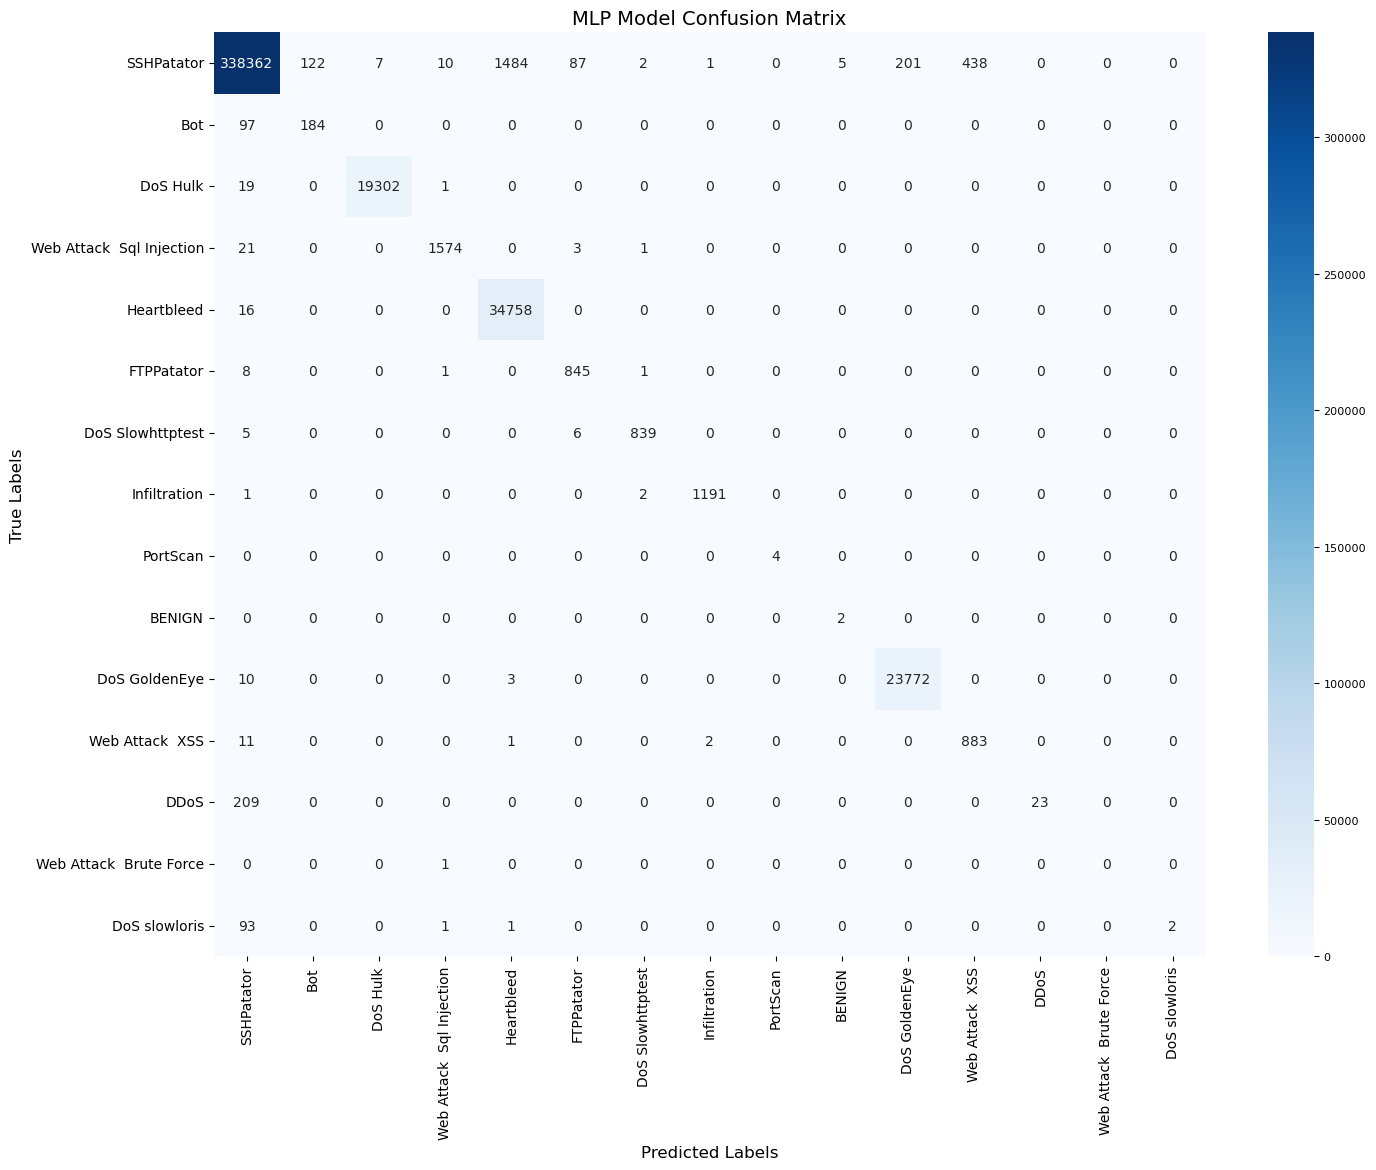

MLP Model Classification Report:


/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                           precision    recall  f1-score   support

               SSHPatator       1.00      0.99      1.00    340719
                      Bot       0.60      0.65      0.63       281
                 DoS Hulk       1.00      1.00      1.00     19322
Web Attack  Sql Injection       0.99      0.98      0.99      1599
               Heartbleed       0.96      1.00      0.98     34774
               FTPPatator       0.90      0.99      0.94       855
         DoS Slowhttptest       0.99      0.99      0.99       850
             Infiltration       1.00      1.00      1.00      1194
                 PortScan       1.00      1.00      1.00         4
                   BENIGN       0.29      1.00      0.44         2
            DoS GoldenEye       0.99      1.00      1.00     23785
          Web Attack  XSS       0.67      0.98      0.80       897
                     DDoS       1.00      0.10      0.18       232
  Web Attack  Brute Force       0.00      0.00      0.00     

/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [3]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

def train_mlp(X_train, y_train, X_val, y_val, X_test, y_test):
    # Fill NaN values using SimpleImputer
    imputer = SimpleImputer(strategy='mean')  # Use mean to fill NaNs for numerical data
    X_train = imputer.fit_transform(X_train)
    X_val = imputer.transform(X_val)
    X_test = imputer.transform(X_test)
    
    # Initialize MLP model with one hidden layer of 100 units and a fixed random state
    mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
    mlp_model.fit(X_train, y_train)
    
    # Predict on validation and test sets
    val_predictions = mlp_model.predict(X_val)
    test_predictions = mlp_model.predict(X_test)
    
    # Calculate and print accuracy
    val_accuracy = accuracy_score(y_val, val_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Validation Accuracy: {val_accuracy:.6f}")
    print(f"Test Accuracy: {test_accuracy:.6f}")
    
    return test_accuracy, y_test, test_predictions

# Train the model and get predictions
meta_accuracy, y_meta_test, meta_predictions = train_mlp(X_train, y_train, X_val, y_val, X_test, y_test)

# Print test accuracy
print(f"MLP_accuracy: {meta_accuracy:.6f}")

# Confusion matrix
cm_meta = confusion_matrix(y_meta_test, meta_predictions)
plt.figure(figsize=(16, 12))
sns.heatmap(cm_meta, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 10})
plt.title("MLP Model Confusion Matrix", fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)  
plt.show()

# Classification report
print("MLP Model Classification Report:")
print(classification_report(y_meta_test, meta_predictions, target_names=labels))


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

def fill_na_with_median(X):
    imputer = SimpleImputer(strategy='median')
    return imputer.fit_transform(X)

def train_svm(X_train, y_train, X_val, y_val, X_test, y_test):
    # Handle NaN values by filling with median
    X_train = fill_na_with_median(X_train)
    X_val = fill_na_with_median(X_val)
    X_test = fill_na_with_median(X_test)
    
    # Initialize SVM model with a radial basis function kernel (RBF)
    svm_model = SVC(kernel='rbf', random_state=42)
    svm_model.fit(X_train, y_train)
    
    # Predict on validation and test sets
    val_predictions = svm_model.predict(X_val)
    test_predictions = svm_model.predict(X_test)
    
    # Calculate and print accuracy
    val_accuracy = accuracy_score(y_val, val_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Validation Accuracy: {val_accuracy:.6f}")
    print(f"Test Accuracy: {test_accuracy:.6f}")
    
    return test_accuracy, y_test, test_predictions

# Train the model and get predictions
meta_accuracy, y_meta_test, meta_predictions = train_svm(X_train, y_train, X_val, y_val, X_test, y_test)

# Print test accuracy
print(f"SVM_accuracy: {meta_accuracy:.6f}")

# Confusion matrix
cm_meta = confusion_matrix(y_meta_test, meta_predictions)
plt.figure(figsize=(16, 12))
sns.heatmap(cm_meta, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 10})
plt.title("SVM Model Confusion Matrix", fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)  
plt.show()

# Classification report
print("SVM Model Classification Report:")
print(classification_report(y_meta_test, meta_predictions, target_names=labels))


/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: [54]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: [54]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/impute/_base.py:598: UserWarning: Skipping features without any observed values: [54]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier

def train_bagging(X_train, y_train, X_val, y_val, X_test, y_test):
    # Initialize BaggingClassifier with a DecisionTree as base estimator
    bagging_model = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)
    bagging_model.fit(X_train, y_train)
    
    # Predict on validation and test sets
    val_predictions = bagging_model.predict(X_val)
    test_predictions = bagging_model.predict(X_test)
    
    # Calculate and print accuracy
    val_accuracy = accuracy_score(y_val, val_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Validation Accuracy: {val_accuracy:.6f}")
    print(f"Test Accuracy: {test_accuracy:.6f}")
    
    return test_accuracy, y_test, test_predictions

# Train the model and get predictions
meta_accuracy, y_meta_test, meta_predictions = train_bagging(X_train, y_train, X_val, y_val, X_test, y_test)

# Print test accuracy
print(f"Bagging_accuracy: {meta_accuracy:.6f}")

# Confusion matrix
cm_meta = confusion_matrix(y_meta_test, meta_predictions)
plt.figure(figsize=(16, 12))
sns.heatmap(cm_meta, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 10})
plt.title("Bagging Model Confusion Matrix", fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)  
plt.show()

# Classification report
print("Bagging Model Classification Report:")
print(classification_report(y_meta_test, meta_predictions, target_names=labels))


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def train_knn(X_train, y_train, X_val, y_val, X_test, y_test):
    # Initialize KNN classifier with 5 neighbors
    knn_model = KNeighborsClassifier(n_neighbors=5)
    knn_model.fit(X_train, y_train)
    
    # Predict on validation and test sets
    val_predictions = knn_model.predict(X_val)
    test_predictions = knn_model.predict(X_test)
    
    # Calculate and print accuracy
    val_accuracy = accuracy_score(y_val, val_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Validation Accuracy: {val_accuracy:.6f}")
    print(f"Test Accuracy: {test_accuracy:.6f}")
    
    return test_accuracy, y_test, test_predictions

# Train the model and get predictions
meta_accuracy, y_meta_test, meta_predictions = train_knn(X_train, y_train, X_val, y_val, X_test, y_test)

# Print test accuracy
print(f"KNN_accuracy: {meta_accuracy:.6f}")

# Confusion matrix
cm_meta = confusion_matrix(y_meta_test, meta_predictions)
plt.figure(figsize=(16, 12))
sns.heatmap(cm_meta, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 10})
plt.title("KNN Model Confusion Matrix", fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)  
plt.show()

# Classification report
print("KNN Model Classification Report:")
print(classification_report(y_meta_test, meta_predictions, target_names=labels))


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def train_adaboost(X_train, y_train, X_val, y_val, X_test, y_test):
    # Initialize AdaBoostClassifier without explicitly defining base_estimator (default is DecisionTree)
    adaboost_model = AdaBoostClassifier(n_estimators=100, random_state=42)
    adaboost_model.fit(X_train, y_train)
    
    # Predict on validation and test sets
    val_predictions = adaboost_model.predict(X_val)
    test_predictions = adaboost_model.predict(X_test)
    
    # Calculate and print accuracy
    val_accuracy = accuracy_score(y_val, val_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Validation Accuracy: {val_accuracy:.6f}")
    print(f"Test Accuracy: {test_accuracy:.6f}")
    
    return test_accuracy, y_test, test_predictions

# Train the model and get predictions
meta_accuracy, y_meta_test, meta_predictions = train_adaboost(X_train, y_train, X_val, y_val, X_test, y_test)

# Print test accuracy
print(f"AdaBoost_accuracy: {meta_accuracy:.6f}")

# Confusion matrix
cm_meta = confusion_matrix(y_meta_test, meta_predictions)
plt.figure(figsize=(16, 12))
sns.heatmap(cm_meta, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 10})
plt.title("AdaBoost Model Confusion Matrix", fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)  
plt.show()

# Classification report
print("AdaBoost Model Classification Report:")
print(classification_report(y_meta_test, meta_predictions, target_names=labels))


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def train_decision_tree(X_train, y_train, X_val, y_val, X_test, y_test):
    # Initialize DecisionTreeClassifier
    dt_model = DecisionTreeClassifier(random_state=42)
    dt_model.fit(X_train, y_train)
    
    # Predict on validation and test sets
    val_predictions = dt_model.predict(X_val)
    test_predictions = dt_model.predict(X_test)
    
    # Calculate and print accuracy
    val_accuracy = accuracy_score(y_val, val_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Validation Accuracy: {val_accuracy:.6f}")
    print(f"Test Accuracy: {test_accuracy:.6f}")
    
    return test_accuracy, y_test, test_predictions

# Train the model and get predictions
meta_accuracy, y_meta_test, meta_predictions = train_decision_tree(X_train, y_train, X_val, y_val, X_test, y_test)

# Print test accuracy
print(f"DecisionTree_accuracy: {meta_accuracy:.6f}")

# Confusion matrix
cm_meta = confusion_matrix(y_meta_test, meta_predictions)
plt.figure(figsize=(16, 12))
sns.heatmap(cm_meta, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 10})
plt.title("Decision Tree Model Confusion Matrix", fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)  
plt.show()

# Classification report
print("Decision Tree Model Classification Report:")
print(classification_report(y_meta_test, meta_predictions, target_names=labels))


In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def train_xgboost(X_train, y_train, X_val, y_val, X_test, y_test):
    # Initialize XGBClassifier
    xgboost_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
    xgboost_model.fit(X_train, y_train)
    
    # Predict on validation and test sets
    val_predictions = xgboost_model.predict(X_val)
    test_predictions = xgboost_model.predict(X_test)
    
    # Calculate and print accuracy
    val_accuracy = accuracy_score(y_val, val_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Validation Accuracy: {val_accuracy:.6f}")
    print(f"Test Accuracy: {test_accuracy:.6f}")
    
    return test_accuracy, y_test, test_predictions

# Train the model and get predictions
meta_accuracy, y_meta_test, meta_predictions = train_xgboost(X_train, y_train, X_val, y_val, X_test, y_test)

# Print test accuracy
print(f"XGBoost_accuracy: {meta_accuracy:.6f}")

# Confusion matrix
cm_meta = confusion_matrix(y_meta_test, meta_predictions)
plt.figure(figsize=(16, 12))
sns.heatmap(cm_meta, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 10})
plt.title("XGBoost Model Confusion Matrix", fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)  
plt.show()

# Classification report
print("XGBoost Model Classification Report:")
print(classification_report(y_meta_test, meta_predictions, target_names=labels))


In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def train_catboost(X_train, y_train, X_val, y_val, X_test, y_test):
    # Initialize CatBoostClassifier
    catboost_model = CatBoostClassifier(random_state=42, iterations=1000, learning_rate=0.1, depth=6, cat_features=[])
    catboost_model.fit(X_train, y_train, cat_features=[], verbose=100)  # verbose=100 for progress info
    
    # Predict on validation and test sets
    val_predictions = catboost_model.predict(X_val)
    test_predictions = catboost_model.predict(X_test)
    
    # Calculate and print accuracy
    val_accuracy = accuracy_score(y_val, val_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Validation Accuracy: {val_accuracy:.6f}")
    print(f"Test Accuracy: {test_accuracy:.6f}")
    
    return test_accuracy, y_test, test_predictions

# Train the model and get predictions
meta_accuracy, y_meta_test, meta_predictions = train_catboost(X_train, y_train, X_val, y_val, X_test, y_test)

# Print test accuracy
print(f"CatBoost_accuracy: {meta_accuracy:.6f}")

# Confusion matrix
cm_meta = confusion_matrix(y_meta_test, meta_predictions)
plt.figure(figsize=(16, 12))
sns.heatmap(cm_meta, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 10})
plt.title("CatBoost Model Confusion Matrix", fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)  
plt.show()

# Classification report
print("CatBoost Model Classification Report:")
print(classification_report(y_meta_test, meta_predictions, target_names=labels))


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def train_gnb(X_train, y_train, X_val, y_val, X_test, y_test):
    # Initialize GNB classifier
    gnb_model = GaussianNB()
    gnb_model.fit(X_train, y_train)
    
    # Predict on validation and test sets
    val_predictions = gnb_model.predict(X_val)
    test_predictions = gnb_model.predict(X_test)
    
    # Calculate and print accuracy
    val_accuracy = accuracy_score(y_val, val_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Validation Accuracy: {val_accuracy:.6f}")
    print(f"Test Accuracy: {test_accuracy:.6f}")
    
    return test_accuracy, y_test, test_predictions

# Train the model and get predictions
meta_accuracy, y_meta_test, meta_predictions = train_gnb(X_train, y_train, X_val, y_val, X_test, y_test)

# Print test accuracy
print(f"GNB_accuracy: {meta_accuracy:.6f}")

# Confusion matrix
cm_meta = confusion_matrix(y_meta_test, meta_predictions)
plt.figure(figsize=(16, 12))
sns.heatmap(cm_meta, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 10})
plt.title("GNB Model Confusion Matrix", fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)  
plt.show()

# Classification report
print("GNB Model Classification Report:")
print(classification_report(y_meta_test, meta_predictions, target_names=labels))


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def train_lr(X_train, y_train, X_val, y_val, X_test, y_test):
    # Initialize Logistic Regression model
    lr_model = LogisticRegression(max_iter=1000, random_state=42)
    lr_model.fit(X_train, y_train)
    
    # Predict on validation and test sets
    val_predictions = lr_model.predict(X_val)
    test_predictions = lr_model.predict(X_test)
    
    # Calculate and print accuracy
    val_accuracy = accuracy_score(y_val, val_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Validation Accuracy: {val_accuracy:.6f}")
    print(f"Test Accuracy: {test_accuracy:.6f}")
    
    return test_accuracy, y_test, test_predictions

# Train the model and get predictions
meta_accuracy, y_meta_test, meta_predictions = train_lr(X_train, y_train, X_val, y_val, X_test, y_test)

# Print test accuracy
print(f"LR_accuracy: {meta_accuracy:.6f}")

# Confusion matrix
cm_meta = confusion_matrix(y_meta_test, meta_predictions)
plt.figure(figsize=(16, 12))
sns.heatmap(cm_meta, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 10})
plt.title("LR Model Confusion Matrix", fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)  
plt.show()

# Classification report
print("LR Model Classification Report:")
print(classification_report(y_meta_test, meta_predictions, target_names=labels))


In [ ]:
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def train_ridge(X_train, y_train, X_val, y_val, X_test, y_test):
    # Initialize Ridge Classifier
    ridge_model = RidgeClassifier(random_state=42)
    ridge_model.fit(X_train, y_train)
    
    # Predict on validation and test sets
    val_predictions = ridge_model.predict(X_val)
    test_predictions = ridge_model.predict(X_test)
    
    # Calculate and print accuracy
    val_accuracy = accuracy_score(y_val, val_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Validation Accuracy: {val_accuracy:.6f}")
    print(f"Test Accuracy: {test_accuracy:.6f}")
    
    return test_accuracy, y_test, test_predictions

# Train the model and get predictions
meta_accuracy, y_meta_test, meta_predictions = train_ridge(X_train, y_train, X_val, y_val, X_test, y_test)

# Print test accuracy
print(f"RidgeClassifier_accuracy: {meta_accuracy:.6f}")

# Confusion matrix
cm_meta = confusion_matrix(y_meta_test, meta_predictions)
plt.figure(figsize=(16, 12))
sns.heatmap(cm_meta, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 10})
plt.title("RC Model Confusion Matrix", fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)  
plt.show()

# Classification report
print("RC Model Classification Report:")
print(classification_report(y_meta_test, meta_predictions, target_names=labels))
